# AvalPocket — ¿Vale la pena la Hipoteca Pignorada?
### Un análisis cuantitativo para la compra de vivienda en España

Este cuaderno compara matemáticamente tres formas de financiar la compra de un piso partiendo de una cartera de inversión ya formada. La pregunta es sencilla: **¿conviene vender los ahorros para pagar la entrada o usarlos como aval y pedir el 100%?**

---

### Conceptos clave (antes de empezar)

| Término | ¿Qué significa en la práctica? |
|---|---|
| **Hipoteca Pignorada** | El banco acepta tu cartera de acciones/fondos como garantía y te presta el 100% del valor del piso. No vendes nada; tus ahorros siguen invertidos y generando rentabilidad. |
| **DCA (Dollar Cost Averaging)** | Estrategia de inversión que consiste en meter una cantidad fija de dinero en bolsa todos los meses, independientemente de si el mercado sube o baja. Es la estrategia más recomendada para el largo plazo. |
| **Interés compuesto** | Tus ganancias generan más ganancias. Cuanto mayor sea el capital inicial invertido, más potente es el efecto exponencial a lo largo de los años. |

---

### Los tres modelos que comparo

**Modelo 1 — Tradicional sin inversión**
- Vendemos toda la cartera para pagar la entrada (20%) y los gastos (10% del valor del piso).
- La cuota hipotecaria es la más baja de los tres modelos.
- El sobrante mensual va a una cuenta corriente al 0% de interés. No se invierte nada.

**Modelo 2 — Tradicional + DCA**
- Igual que el modelo 1: vendemos la cartera para pagar la entrada.
- Diferencia: el ahorro mensual que nos sobra (diferencia de cuota respecto a la pignorada + 400 € adicionales) lo invertimos mes a mes en bolsa.

**Modelo 3 — Hipoteca Pignorada**
- No vendemos nada. Los 60.000 € permanecen invertidos desde el día 1, funcionando como aval.
- Al pedir el 100% del préstamo, la cuota mensual es algo mayor.
- Invertimos 400 € adicionales al mes.

> **Fuentes de datos:** Cotización histórica del S&P 500 descargada desde Yahoo Finance. Tipos de interés del Banco Santander (oferta 2026). Piso de 250.000 € en Oviedo con revalorización histórica del 2,5% anual.

## ⚠️ Aviso previo — Lee esto antes de usar los resultados

Este cuaderno es un **ejercicio analítico con fines educativos**. Los modelos simplifican la realidad y los resultados dependen de supuestos (rentabilidades pasadas, tipos de interés, inflación, fiscalidad vigente) que pueden no repetirse en el futuro.

**No constituye asesoramiento financiero, fiscal ni legal.** Antes de tomar una decisión sobre una hipoteca —y muy especialmente sobre una hipoteca pignorada— consulta con un asesor financiero habilitado (EAF, CNMV) y con tu gestor fiscal.

La versión ampliada del disclaimer está al final del cuaderno (sección 9).

In [45]:
import warnings
warnings.filterwarnings('ignore')

import yfinance as yf
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Estilo global coherente en todos los gráficos
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (12, 7),
    'axes.titlesize':  14,
    'axes.labelsize':  12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 11,
    'legend.framealpha': 0.9,
})

# Paleta de colores consistente en todo el análisis
C_CASH   = '#C0392B'   # rojo   → Tradicional sin inversión
C_DCA    = '#D35400'   # naranja → Tradicional + DCA
C_PLEDGE = '#1E8449'   # verde  → Hipoteca Pignorada

## 1. Datos históricos: S&P 500 (1995–2024)

Antes de simular nada, merece la pena ver cómo se ha comportado el mercado durante los últimos 30 años. La rentabilidad media anual del S&P 500 ronda el **9–10 %**, pero con una dispersión enorme: hubo años de +30 % y también años de −38 % (2008). Esta volatilidad es exactamente lo que hace tan importante el capital inicial que se mantiene invertido.

Período descargado : 1996 – 2024
Rentabilidad media : 9.7% anual
Desviación estándar: 17.7% (medida de volatilidad)


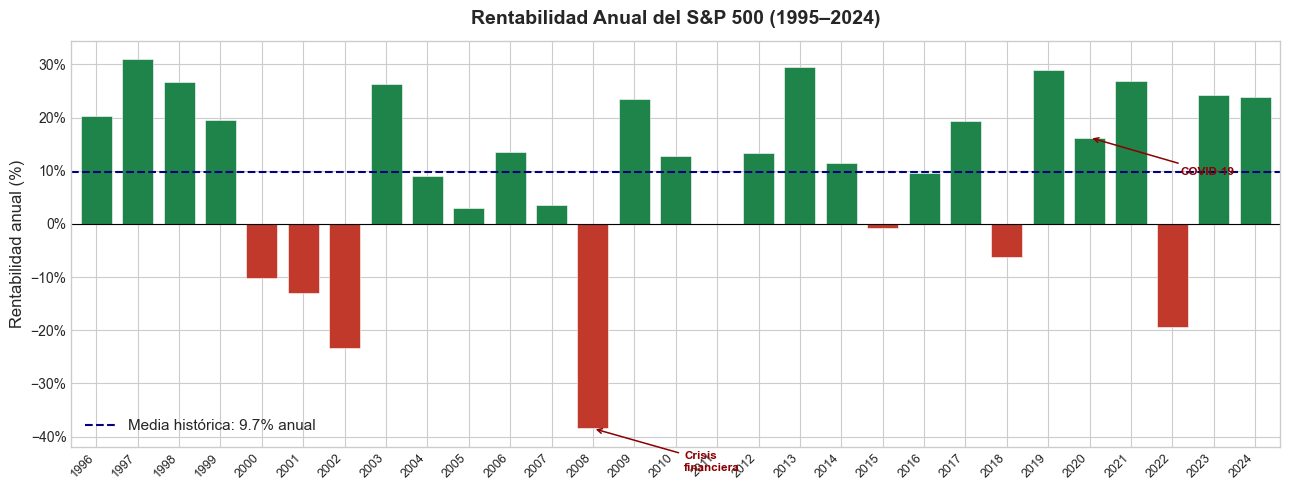

In [46]:
def fetch_sp500_returns(start='1995-01-01', end='2024-12-31'):
    data = yf.download('^GSPC', start=start, end=end, progress=False)
    try:
        series = data['Adj Close']
    except KeyError:
        series = data['Close']
    if isinstance(series, pd.DataFrame):
        series = series.iloc[:, 0]
    return series.resample('YE').last().pct_change().dropna()

returns_sp500 = fetch_sp500_returns()
mean_r = returns_sp500.mean()
std_r  = returns_sp500.std()

print(f"Período descargado : {returns_sp500.index[0].year} – {returns_sp500.index[-1].year}")
print(f"Rentabilidad media : {mean_r*100:.1f}% anual")
print(f"Desviación estándar: {std_r*100:.1f}% (medida de volatilidad)")

# --- Gráfico de barras: rentabilidades anuales ---
years_label = [str(y.year) for y in returns_sp500.index]
colors_bar  = [C_PLEDGE if r > 0 else C_CASH for r in returns_sp500.values]

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(range(len(years_label)), returns_sp500.values * 100,
       color=colors_bar, edgecolor='white', linewidth=0.4, width=0.75)
ax.axhline(0, color='black', linewidth=0.8)
ax.axhline(mean_r * 100, color='navy', linewidth=1.5, linestyle='--',
           label=f'Media histórica: {mean_r*100:.1f}% anual')

# Anotaciones para las grandes crisis
for year_str, offset_y, label in [('2008', -8, 'Crisis\nfinanciera'), ('2020', -7, 'COVID-19')]:
    if year_str in years_label:
        idx = years_label.index(year_str)
        ax.annotate(label, xy=(idx, returns_sp500.values[idx] * 100),
                    xytext=(idx + 2.2, returns_sp500.values[idx] * 100 + offset_y),
                    fontsize=8.5, color='darkred', fontweight='bold',
                    arrowprops=dict(arrowstyle='->', color='darkred', lw=1.1))

ax.set_title('Rentabilidad Anual del S&P 500 (1995–2024)', fontweight='bold', pad=12)
ax.set_ylabel('Rentabilidad anual (%)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_xticks(range(len(years_label)))
ax.set_xticklabels(years_label, rotation=45, ha='right', fontsize=9)
ax.legend()
ax.set_xlim(-0.6, len(years_label) - 0.4)
plt.tight_layout()
plt.savefig('figures/sp500_returns.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Motor de cálculo financiero

Las funciones siguientes implementan la matemática detrás de cada modelo:

- **`calculate_monthly_payment`** — Cuota mensual en sistema francés (amortización constante).
- **`capital_gains_tax_spain`** — IRPF sobre plusvalías según los tramos vigentes en España (2024/2025).
- **`simulate_pledged`** — Modelo pignorado: el capital inicial permanece invertido y crece con el mercado mes a mes.
- **`simulate_traditional_dca`** — Modelo tradicional con reinversión mensual del ahorro generado.
- **`simulate_traditional_cash`** — Modelo tradicional sin inversión (ahorro en cuenta corriente al 0%).

In [ ]:
def calculate_monthly_payment(principal, annual_rate, years):
    """Cuota mensual — sistema francés (amortización constante)."""
    r = annual_rate / 12
    n = years * 12
    return principal * (r * (1 + r)**n) / ((1 + r)**n - 1)


def capital_gains_tax_spain(gain):
    """IRPF sobre plusvalías según tramos España 2024/2025."""
    if gain <= 0:
        return 0
    brackets = [
        ( 6_000, 0.19),
        ( 50_000, 0.21),
        (200_000, 0.23),
        (300_000, 0.27),
        (float('inf'), 0.28),
    ]
    tax = taxed = 0
    for limit, rate in brackets:
        taxable = min(gain - taxed, limit - taxed)
        if taxable <= 0:
            break
        tax   += taxable * rate
        taxed += taxable
    return tax


def _amortize_one_month(debt, monthly_payment, interest_rate):
    """Paga un mes de hipoteca sin sobrepasar el saldo pendiente."""
    if debt <= 0:       #si la deuda es menor que 0
        return 0.0  
    interest_charge = debt * (interest_rate / 12)
    principal_paid  = min(monthly_payment - interest_charge, debt)
    return debt - principal_paid


def simulate_pledged(home_price, initial_capital, mortgage_years, interest_rate,
                     annual_returns, housing_rate, extra_monthly_savings=0,
                     ter=0.0, life_insurance_rate=0.0, home_insurance_annual=0.0):
    """
    Modelo Pignorado: no se venden activos.
    El capital inicial (menos gastos de compra) sigue invertido y crece con el mercado.
    Se pide hipoteca por el 100% del precio de la vivienda.
    """
    purchase_costs   = home_price * 0.10          # gastos escritura, impuestos, etc.
    mortgage_amount  = home_price
    portfolio_value  = initial_capital - purchase_costs
    current_home_val = home_price
    monthly_payment  = calculate_monthly_payment(mortgage_amount, interest_rate, mortgage_years)
    debt             = mortgage_amount
    history          = []

    for annual_r in annual_returns:
        monthly_r = (1 + annual_r - ter) ** (1 / 12) - 1
        current_home_val *= (1 + housing_rate)
        for _ in range(12):
            insurance = debt * (life_insurance_rate / 12) + home_insurance_annual / 12
            portfolio_value += max(0, extra_monthly_savings - insurance)
            portfolio_value *= (1 + monthly_r)
            debt = _amortize_one_month(debt, monthly_payment, interest_rate)
        history.append(current_home_val + portfolio_value - debt)
    return history, mortgage_amount, monthly_payment


def simulate_traditional_dca(home_price, initial_capital, cost_basis, mortgage_years,
                              interest_rate, annual_returns, housing_rate,
                              monthly_budget, extra_monthly_savings=0,
                              ter=0.0, life_insurance_rate=0.0, home_insurance_annual=0.0):
    """
    Modelo Tradicional + DCA:
    Se vende la cartera, se pagan plusvalías, se usa el efectivo neto para dar
    la entrada (20%) más los gastos (10%). El sobrante y el ahorro mensual
    (diferencia de cuota + extra) se invierten en bolsa cada mes.
    """
    gain            = max(0, initial_capital - cost_basis)
    tax             = capital_gains_tax_spain(gain)
    net_cash        = initial_capital - tax
    total_needed    = home_price * 0.20 + home_price * 0.10
    mortgage_amount = home_price * 0.80
    monthly_payment = calculate_monthly_payment(mortgage_amount, interest_rate, mortgage_years)
    leftover        = max(0, net_cash - total_needed)
    portfolio_value = leftover
    monthly_savings = max(0, monthly_budget - monthly_payment) + extra_monthly_savings
    debt            = mortgage_amount
    current_home_val = home_price
    history         = []

    for annual_r in annual_returns:
        monthly_r = (1 + annual_r - ter) ** (1 / 12) - 1
        current_home_val *= (1 + housing_rate)
        for _ in range(12):
            insurance = debt * (life_insurance_rate / 12) + home_insurance_annual / 12
            portfolio_value += max(0, monthly_savings - insurance)
            portfolio_value *= (1 + monthly_r)
            debt = _amortize_one_month(debt, monthly_payment, interest_rate)
        history.append(current_home_val + portfolio_value - debt)
    return history, mortgage_amount, monthly_payment, tax, leftover


def simulate_traditional_cash(home_price, initial_capital, cost_basis, mortgage_years,
                               interest_rate, annual_returns, housing_rate,
                               monthly_budget, extra_monthly_savings=0,
                               life_insurance_rate=0.0, home_insurance_annual=0.0):
    """
    Modelo Tradicional sin inversión:
    Igual que el DCA pero el sobrante mensual va a cuenta corriente (0% de rentabilidad).
    """
    gain             = max(0, initial_capital - cost_basis)
    tax              = capital_gains_tax_spain(gain)
    net_cash         = initial_capital - tax
    total_needed     = home_price * 0.20 + home_price * 0.10
    mortgage_amount  = home_price * 0.80
    monthly_payment  = calculate_monthly_payment(mortgage_amount, interest_rate, mortgage_years)
    leftover         = max(0, net_cash - total_needed)
    cash_account     = leftover
    monthly_savings  = max(0, monthly_budget - monthly_payment) + extra_monthly_savings
    debt             = mortgage_amount
    current_home_val = home_price
    history          = []

    for annual_r in annual_returns:
        current_home_val *= (1 + housing_rate)
        for _ in range(12):
            insurance = debt * (life_insurance_rate / 12) + home_insurance_annual / 12
            cash_account += max(0, monthly_savings - insurance)
            debt = _amortize_one_month(debt, monthly_payment, interest_rate)
        history.append(current_home_val + cash_account - debt)
    return history, mortgage_amount, monthly_payment

## 3. Parámetros del caso real

He intentado que los datos sean lo más reales posible:

| Parámetro | Valor | Fuente |
|---|---|---|
| Precio de la vivienda | 250.000 € | Piso en Oviedo (mercado 2026) |
| Capital inicial invertido | 60.000 € | — |
| Coste de adquisición de la cartera | 40.000 € | (para calcular plusvalías a Hacienda) |
| Duración hipoteca | 25 años | — |
| TIN hipoteca tradicional (80%) | 2,81% | Banco Santander, oferta mayo 2026 |
| TIN hipoteca pignorada (100%) | 3,31% | +0,50% por el riesgo adicional del banco |
| Revalorización anual de la vivienda | 2,5% | Media histórica España |
| Ahorro extra mensual (ambos modelos) | 400 € | — |
| Datos de mercado | S&P 500, 1996–2020 | Yahoo Finance |
| TER del fondo (comisión anual) | 0,20% | Vanguard / Amundi |
| Seguro de vida (% del capital pendiente) | 0,40%/año | Mercado español |
| Seguro de hogar | 350 €/año | Mercado español |

  COMPARATIVA DE CUOTAS Y FLUJOS MENSUALES
  Presupuesto mensual total (referencia):    1626 €/mes
  ────────────────────────────────────────────────
  Modelo Pignorado
    · Cuota hipotecaria (250.000 € al 3,31%):   1226 €
    · Inversión mensual nueva:                   400 €
    · Capital base que sigue invertido:       35,000 €
  ────────────────────────────────────────────────
  Modelo Tradicional
    · Cuota hipotecaria (120.000 € al 2,81%):    929 €
    · Inversión mensual DCA:                     697 €
    · Capital inicial invertido:                   0 €
    · Impuestos pagados al vender:             4,080 €

  PATRIMONIO NETO AL AÑO 25
  Tradicional sin inversión (0%):       652,778 €
  Tradicional + DCA:                    979,766 €
  Hipoteca Pignorada:                   928,208 €
  ────────────────────────────────────────
  Ventaja Pignorada vs DCA:             -51,558 €


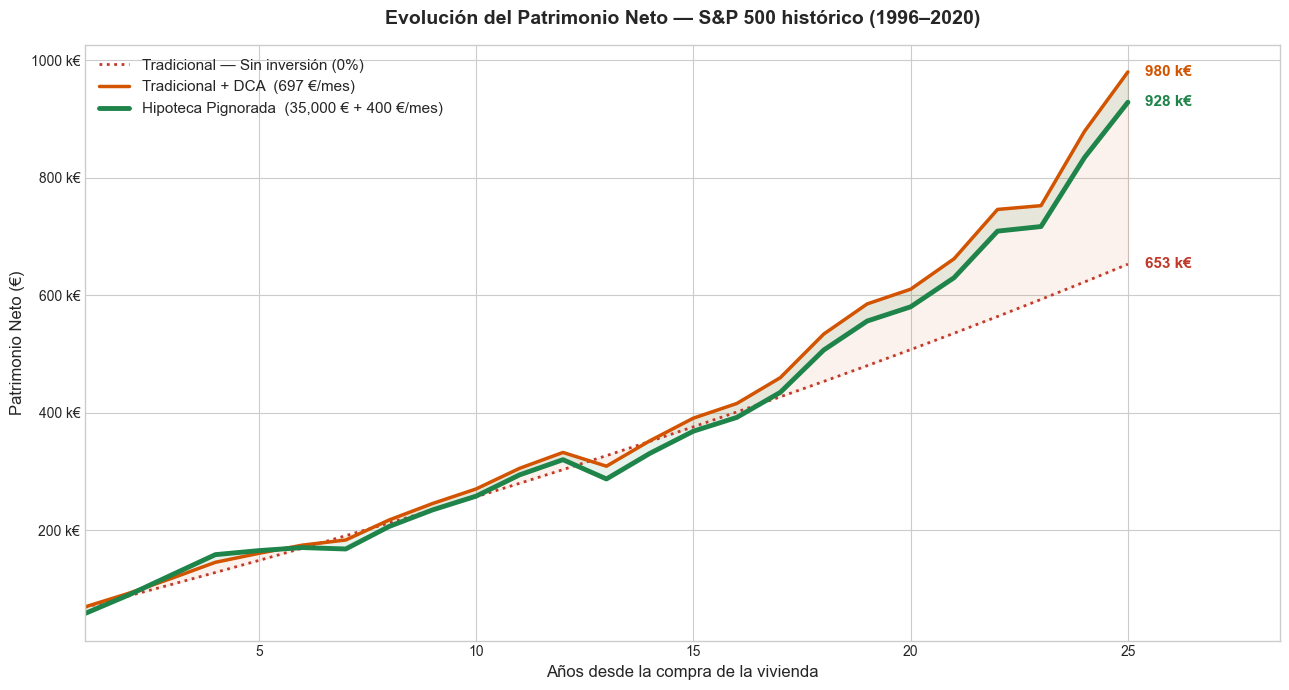

In [48]:
# --- Parámetros ---
HOME_PRICE            = 250_000
INITIAL_CAPITAL       = 60_000
COST_BASIS            = 40_000           # coste de adquisición de la cartera (base para plusvalías en Hacienda)
MORTGAGE_YEARS        = 25
TIN_TRADITIONAL       = 0.0281
TIN_PLEDGED           = 0.0331
HOUSING_APPRECIATION  = 0.025
EXTRA_MONTHLY_SAVINGS = 400
TER                   = 0.0020   # comisión anual del fondo indexado
LIFE_INSURANCE_RATE   = 0.0040   # seguro de vida (% capital pendiente / año)
HOME_INSURANCE_ANNUAL = 350      # seguro de hogar (€/año)

returns_slice = returns_sp500.head(MORTGAGE_YEARS).values   # 1996–2020

# --- Simulaciones ---
pledge_hist, pledge_mortgage, pledge_payment = simulate_pledged(
    HOME_PRICE, INITIAL_CAPITAL, MORTGAGE_YEARS, TIN_PLEDGED,
    returns_slice, HOUSING_APPRECIATION, EXTRA_MONTHLY_SAVINGS,
    ter=TER, life_insurance_rate=LIFE_INSURANCE_RATE, home_insurance_annual=HOME_INSURANCE_ANNUAL
)
dca_hist, dca_mortgage, dca_payment, trad_tax, dca_leftover = simulate_traditional_dca(
    HOME_PRICE, INITIAL_CAPITAL, COST_BASIS, MORTGAGE_YEARS, TIN_TRADITIONAL,
    returns_slice, HOUSING_APPRECIATION, pledge_payment, EXTRA_MONTHLY_SAVINGS,
    ter=TER, life_insurance_rate=LIFE_INSURANCE_RATE, home_insurance_annual=HOME_INSURANCE_ANNUAL
)
cash_hist, _, _ = simulate_traditional_cash(
    HOME_PRICE, INITIAL_CAPITAL, COST_BASIS, MORTGAGE_YEARS, TIN_TRADITIONAL,
    returns_slice, HOUSING_APPRECIATION, pledge_payment, EXTRA_MONTHLY_SAVINGS,
    life_insurance_rate=LIFE_INSURANCE_RATE, home_insurance_annual=HOME_INSURANCE_ANNUAL
)

dca_monthly_invest = (pledge_payment - dca_payment) + EXTRA_MONTHLY_SAVINGS

print("=" * 60)
print("  COMPARATIVA DE CUOTAS Y FLUJOS MENSUALES")
print("=" * 60)
print(f"  Presupuesto mensual total (referencia): {pledge_payment + EXTRA_MONTHLY_SAVINGS:>7.0f} €/mes")
print(f"  {'─'*48}")
print(f"  Modelo Pignorado")
print(f"    · Cuota hipotecaria (250.000 € al 3,31%): {pledge_payment:>6.0f} €")
print(f"    · Inversión mensual nueva:                {EXTRA_MONTHLY_SAVINGS:>6} €")
print(f"    · Capital base que sigue invertido:       {INITIAL_CAPITAL - HOME_PRICE*0.10:>6,.0f} €")
print(f"  {'─'*48}")
print(f"  Modelo Tradicional")
print(f"    · Cuota hipotecaria (120.000 € al 2,81%): {dca_payment:>6.0f} €")
print(f"    · Inversión mensual DCA:                  {dca_monthly_invest:>6.0f} €")
print(f"    · Capital inicial invertido:              {dca_leftover:>6,.0f} €")
print(f"    · Impuestos pagados al vender:            {trad_tax:>6,.0f} €")
print()
print("=" * 60)
print("  PATRIMONIO NETO AL AÑO 25")
print("=" * 60)
print(f"  Tradicional sin inversión (0%):  {cash_hist[-1]:>12,.0f} €")
print(f"  Tradicional + DCA:               {dca_hist[-1]:>12,.0f} €")
print(f"  Hipoteca Pignorada:              {pledge_hist[-1]:>12,.0f} €")
print(f"  {'─'*40}")
diff = pledge_hist[-1] - dca_hist[-1]
print(f"  Ventaja Pignorada vs DCA:        {diff:>+12,.0f} €")
print("=" * 60)

# --- Gráfico: evolución del patrimonio ---
fig, ax = plt.subplots(figsize=(13, 7))
years = list(range(1, MORTGAGE_YEARS + 1))

ax.fill_between(years, dca_hist, pledge_hist, alpha=0.10, color=C_PLEDGE)
ax.fill_between(years, cash_hist, dca_hist,   alpha=0.07, color=C_DCA)

ax.plot(years, cash_hist,   color=C_CASH,   linewidth=2,   linestyle=':',
        label='Tradicional — Sin inversión (0%)')
ax.plot(years, dca_hist,    color=C_DCA,    linewidth=2.5,
        label=f'Tradicional + DCA  ({dca_monthly_invest:.0f} €/mes)')
ax.plot(years, pledge_hist, color=C_PLEDGE, linewidth=3.5,
        label=f'Hipoteca Pignorada  ({INITIAL_CAPITAL - HOME_PRICE*0.10:,.0f} € + {EXTRA_MONTHLY_SAVINGS} €/mes)')

for val, color in [(cash_hist[-1], C_CASH), (dca_hist[-1], C_DCA), (pledge_hist[-1], C_PLEDGE)]:
    ax.annotate(f'{val/1e3:.0f} k€',
                xy=(MORTGAGE_YEARS, val), xytext=(MORTGAGE_YEARS + 0.4, val),
                color=color, fontweight='bold', va='center', fontsize=11,
                annotation_clip=False)

ax.set_xlim(1, MORTGAGE_YEARS + 3.5)
ax.set_title('Evolución del Patrimonio Neto — S&P 500 histórico (1996–2020)',
             fontweight='bold', pad=15)
ax.set_xlabel('Años desde la compra de la vivienda')
ax.set_ylabel('Patrimonio Neto (€)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f} k€'))
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig('figures/patrimony.png', dpi=150, bbox_inches='tight')
plt.show()

In [49]:
# --- Tabla resumen comparativa ---
final_home = HOME_PRICE * (1 + HOUSING_APPRECIATION) ** MORTGAGE_YEARS

pledge_initial_invested = INITIAL_CAPITAL - HOME_PRICE * 0.10

summary = pd.DataFrame({
    'Modelo': ['Trad. sin inversión', 'Trad. + DCA', 'Pignorada'],
    'Hipoteca': [f'{dca_mortgage:,.0f} €', f'{dca_mortgage:,.0f} €', f'{pledge_mortgage:,.0f} €'],
    'TIN': [f'{TIN_TRADITIONAL*100:.2f}%', f'{TIN_TRADITIONAL*100:.2f}%', f'{TIN_PLEDGED*100:.2f}%'],
    'Cuota/mes': [f'{dca_payment:.0f} €', f'{dca_payment:.0f} €', f'{pledge_payment:.0f} €'],
    'Inversión/mes': ['0 €', f'{dca_monthly_invest:.0f} €', f'{EXTRA_MONTHLY_SAVINGS} €'],
    'Capital inicial invertido': [
        f'{dca_leftover:,.0f} €',
        f'{dca_leftover:,.0f} €',
        f'{pledge_initial_invested:,.0f} €',
    ],
    'Patrimonio año 25': [
        f'{cash_hist[-1]:,.0f} €',
        f'{dca_hist[-1]:,.0f} €',
        f'{pledge_hist[-1]:,.0f} €',
    ],
})

summary = summary.set_index('Modelo')
print(summary.to_string())

                      Hipoteca    TIN Cuota/mes Inversión/mes Capital inicial invertido Patrimonio año 25
Modelo                                                                                                   
Trad. sin inversión  200,000 €  2.81%     929 €           0 €                       0 €         652,778 €
Trad. + DCA          200,000 €  2.81%     929 €         697 €                       0 €         979,766 €
Pignorada            250,000 €  3.31%    1226 €         400 €                  35,000 €         928,208 €


## 4. Análisis de sensibilidad — ¿Cuándo gana y cuándo pierde la Pignorada?

El resultado anterior depende de los datos históricos concretos. Pero, ¿qué pasa si el mercado rinde menos? ¿Y si los tipos de interés suben más?

El mapa de calor siguiente responde a esta pregunta: cruza **6 niveles de rentabilidad de mercado** (del 2% al 12% anual) con **6 niveles de tipo de interés bancario** (del 1% al 6%). El número en cada celda indica cuántos miles de euros extra obtiene el modelo Pignorado respecto al DCA al cabo de 25 años.

- **Verde:** la Pignorada gana. Cuanto más oscuro, mayor ventaja.
- **Rojo:** la Pignorada pierde. Solo ocurre cuando el mercado rinde muy poco y los tipos son altos.

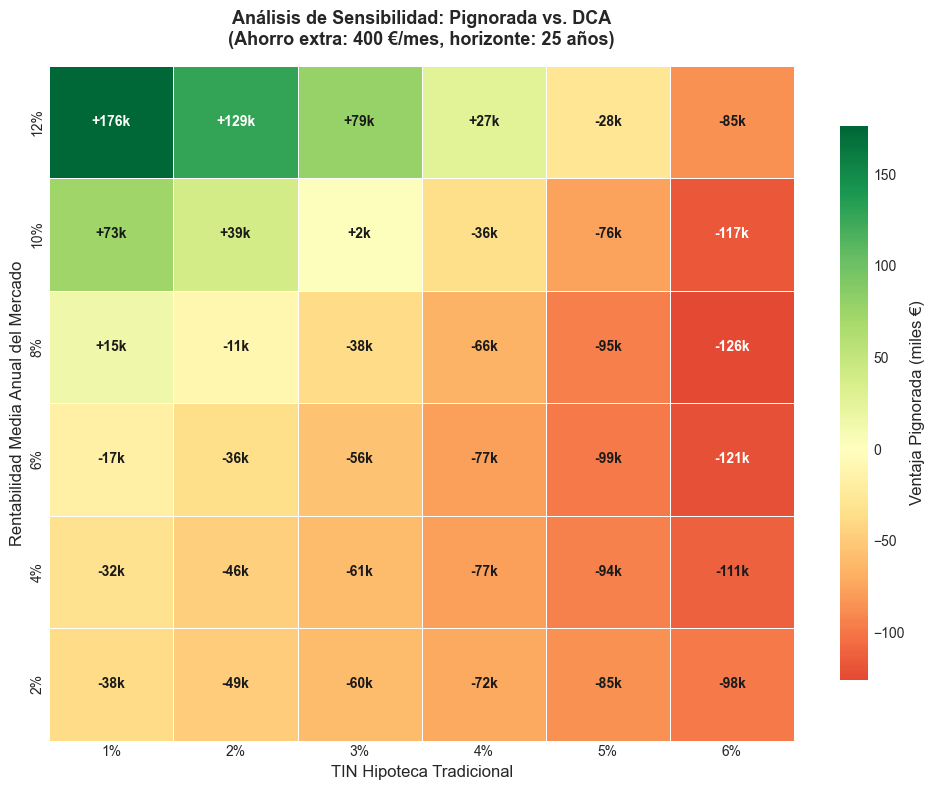

In [50]:
# Supuesto: la pignorada cobra 50 pb más que la tradicional (prima por asumir el banco
# la cartera como garantía). Se aplica en todo el barrido del heatmap.
PLEDGE_SPREAD = 0.005

market_returns_test = np.array([0.02, 0.04, 0.06, 0.08, 0.10, 0.12])
interest_rates_test = np.array([0.01, 0.02, 0.03, 0.04, 0.05, 0.06])
results_matrix      = np.zeros((len(market_returns_test), len(interest_rates_test)))

for i, m_ret in enumerate(market_returns_test):
    sim_rets = np.full(MORTGAGE_YEARS, m_ret)
    for j, i_rate in enumerate(interest_rates_test):
        p_h, _, p_pay = simulate_pledged(
            HOME_PRICE, INITIAL_CAPITAL, MORTGAGE_YEARS, i_rate + PLEDGE_SPREAD,
            sim_rets, HOUSING_APPRECIATION, EXTRA_MONTHLY_SAVINGS
        )
        d_h, _, _, _, _ = simulate_traditional_dca(
            HOME_PRICE, INITIAL_CAPITAL, COST_BASIS, MORTGAGE_YEARS, i_rate,
            sim_rets, HOUSING_APPRECIATION, p_pay, EXTRA_MONTHLY_SAVINGS
        )
        results_matrix[i, j] = (p_h[-1] - d_h[-1]) / 1000

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(results_matrix, annot=False, cmap='RdYlGn', center=0,
            xticklabels=[f'{x*100:.0f}%' for x in interest_rates_test],
            yticklabels=[f'{x*100:.0f}%' for x in market_returns_test],
            ax=ax, cbar_kws={'label': 'Ventaja Pignorada (miles €)', 'shrink': 0.82},
            linewidths=0.5, linecolor='white')

vmax = np.abs(results_matrix).max()
for i in range(results_matrix.shape[0]):
    for j in range(results_matrix.shape[1]):
        val   = results_matrix[i, j]
        label = f'+{val:.0f}k' if val >= 0 else f'{val:.0f}k'
        color = 'white' if abs(val) > vmax * 0.65 else '#1a1a1a'
        ax.text(j + 0.5, i + 0.5, label,
                ha='center', va='center', fontsize=10, fontweight='bold', color=color)

ax.set_title(f'Análisis de Sensibilidad: Pignorada vs. DCA\n(Ahorro extra: {EXTRA_MONTHLY_SAVINGS} €/mes, horizonte: {MORTGAGE_YEARS} años)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('TIN Hipoteca Tradicional')
ax.set_ylabel('Rentabilidad Media Anual del Mercado')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('figures/heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Simulación de Monte Carlo — Midiendo el riesgo real

El análisis con datos históricos usa una sola secuencia de rentabilidades (la que ocurrió entre 1996 y 2020). Para ser rigurosos, hay que preguntarse: **¿qué habría pasado si el mercado hubiera ido de otra manera?**

Usando la técnica estadística de Monte Carlo, he generado **1.000 secuencias de rentabilidades aleatorias** compatibles con la media y la volatilidad históricas del S&P 500. Para cada secuencia, he calculado la diferencia de patrimonio final entre la Pignorada y el DCA.

El gráfico de abanico muestra:
- La **franja azul claro** engloba el 80% de los escenarios posibles (P10–P90).
- La **franja azul oscuro** es el rango central del 50% (P25–P75).
- La **línea roja** es la mediana — el escenario más probable de todos.
- La **línea discontinua en el cero** representa el empate exacto entre los dos modelos.

Probabilidad de que la Pignorada supere al DCA al año 25: 36.6%

Distribución de la ventaja al año 25:
  Percentil 90 (escenario optimista):     +159,559 €
  Percentil 75:                            +44,606 €
  Mediana (escenario más probable):        -27,655 €
  Percentil 25:                            -80,714 €
  Percentil 10 (escenario pesimista):     -139,395 €
  Peor caso absoluto:                     -458,586 €


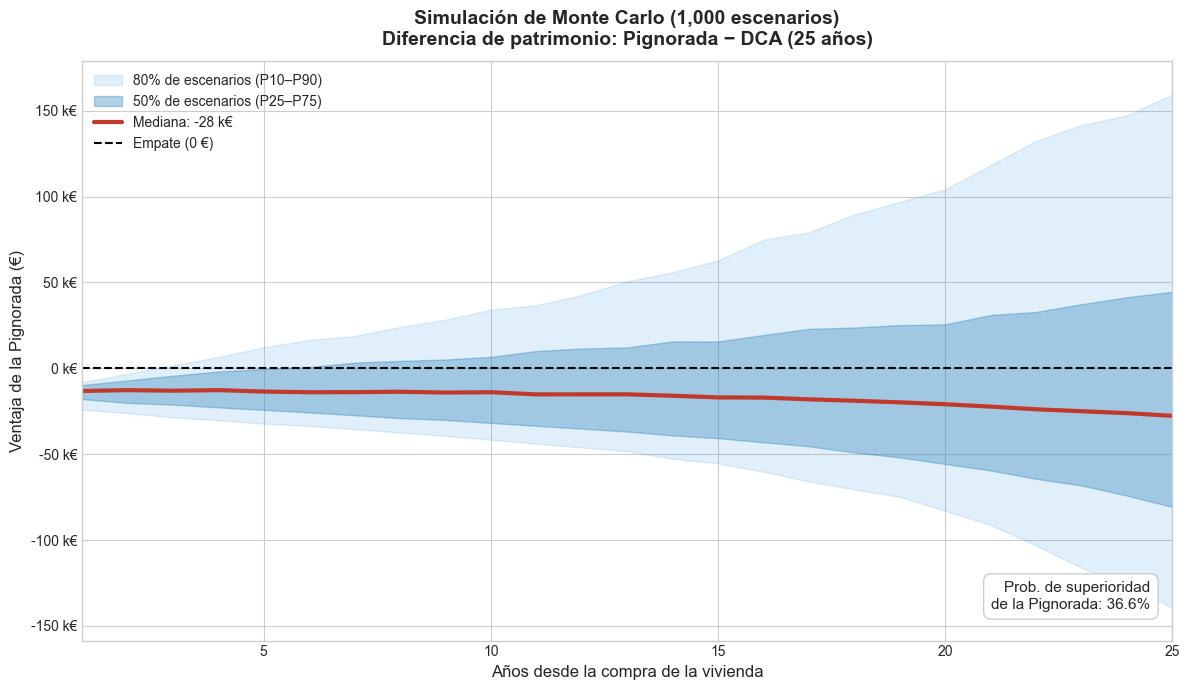

In [51]:
np.random.seed(42)
NUM_SIMULATIONS = 1000
all_paths       = []

# Bootstrap histórico: muestreamos con reemplazo de la serie real del S&P 500.
# A diferencia de una normal, preserva la asimetría y las colas gordas reales
# (grandes crashes como 2008 aparecen con su frecuencia empírica).
historical_returns = returns_sp500.values

for _ in range(NUM_SIMULATIONS):
    r_returns = np.random.choice(historical_returns, size=MORTGAGE_YEARS, replace=True)
    p_h, _, p_pay = simulate_pledged(
        HOME_PRICE, INITIAL_CAPITAL, MORTGAGE_YEARS, TIN_PLEDGED,
        r_returns, HOUSING_APPRECIATION, EXTRA_MONTHLY_SAVINGS
    )
    d_h, _, _, _, _ = simulate_traditional_dca(
        HOME_PRICE, INITIAL_CAPITAL, COST_BASIS, MORTGAGE_YEARS, TIN_TRADITIONAL,
        r_returns, HOUSING_APPRECIATION, p_pay, EXTRA_MONTHLY_SAVINGS
    )
    all_paths.append(np.array(p_h) - np.array(d_h))

all_paths = np.array(all_paths)
p10    = np.percentile(all_paths, 10, axis=0)
p25    = np.percentile(all_paths, 25, axis=0)
median = np.median(all_paths, axis=0)
p75    = np.percentile(all_paths, 75, axis=0)
p90    = np.percentile(all_paths, 90, axis=0)
win_rate = (all_paths[:, -1] > 0).mean() * 100

print(f"Probabilidad de que la Pignorada supere al DCA al año 25: {win_rate:.1f}%")
print()
print("Distribución de la ventaja al año 25:")
print(f"  Percentil 90 (escenario optimista): {p90[-1]:>+12,.0f} €")
print(f"  Percentil 75:                       {p75[-1]:>+12,.0f} €")
print(f"  Mediana (escenario más probable):   {median[-1]:>+12,.0f} €")
print(f"  Percentil 25:                       {p25[-1]:>+12,.0f} €")
print(f"  Percentil 10 (escenario pesimista): {p10[-1]:>+12,.0f} €")
print(f"  Peor caso absoluto:                 {all_paths[:,-1].min():>+12,.0f} €")

# --- Gráfico fan chart ---
fig, ax = plt.subplots(figsize=(12, 7))
years_axis = range(1, MORTGAGE_YEARS + 1)

ax.fill_between(years_axis, p10, p90, color='#3498DB', alpha=0.15,
                label='80% de escenarios (P10–P90)')
ax.fill_between(years_axis, p25, p75, color='#2980B9', alpha=0.35,
                label='50% de escenarios (P25–P75)')
ax.plot(years_axis, median, color='#C0392B', linewidth=3,
        label=f'Mediana: {median[-1]/1e3:+.0f} k€')
ax.axhline(0, color='black', linestyle='--', linewidth=1.5, label='Empate (0 €)')

ax.text(0.98, 0.05,
        f'Prob. de superioridad\nde la Pignorada: {win_rate:.1f}%',
        transform=ax.transAxes, fontsize=11, ha='right', va='bottom',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
                  edgecolor='#cccccc', alpha=0.95))

margin = max(abs(p10.min()), abs(p90.max())) * 0.12
ax.set_ylim(p10.min() - margin, p90.max() + margin)
ax.set_xlim(1, MORTGAGE_YEARS)
ax.set_title(f'Simulación de Monte Carlo ({NUM_SIMULATIONS:,} escenarios)\n'
             f'Diferencia de patrimonio: Pignorada − DCA (25 años)',
             fontweight='bold', pad=12)
ax.set_xlabel('Años desde la compra de la vivienda')
ax.set_ylabel('Ventaja de la Pignorada (€)')
ax.legend(loc='upper left', fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f} k€'))
plt.tight_layout()
plt.savefig('figures/montecarlo.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Comparativa por precio de vivienda

El resultado anterior corresponde a un piso de 250.000 €. Pero, **¿cómo cambia la conclusión si el precio fuese diferente?**

A continuación simulamos los tres modelos para un rango de precios de vivienda (de 100.000 € a 400.000 €), manteniendo el resto de parámetros constantes:
- Capital inicial: 60.000 €
- TIN tradicional (80%): 2,81%
- TIN pignorada (100%): 3,31%
- Ahorro extra mensual: 400 €
- Plazo: 25 años

> **Nota**: A medida que sube el precio, el modelo tradicional necesita más entrada (30% del precio). Si el capital inicial no alcanza, la cartera DCA arranca a cero. En la pignorada, un precio alto implica que los gastos de compra (10%) consumen gran parte del capital inicial, reduciendo el efecto del interés compuesto.

  COMPARATIVA POR PRECIO DE VIVIENDA (25 años, rentabilidades históricas S&P 500)
      Precio     Entrada   Cuota Pig   Cuota Trad     Patr.Cash      Patr.DCA     Patr.Pign     Vent.Real   Viable
  ────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     100,000      30,000         490          372       396,539     1,080,263     1,132,050       +20,745       Sí
     150,000      45,000         736          557       502,323     1,115,760     1,174,917       +22,640       Sí
     200,000      60,000         981          743       612,188     1,188,304     1,217,784        +7,580       No
     250,000      75,000       1,226          929       732,972     1,360,007     1,260,650       -52,860       No
     300,000      90,000       1,471        1,115       853,756     1,531,710     1,303,517      -113,301       No
     350,000     105,000       1,717        1,300       974,541     1,703,413     1,346,384      -173,741       N

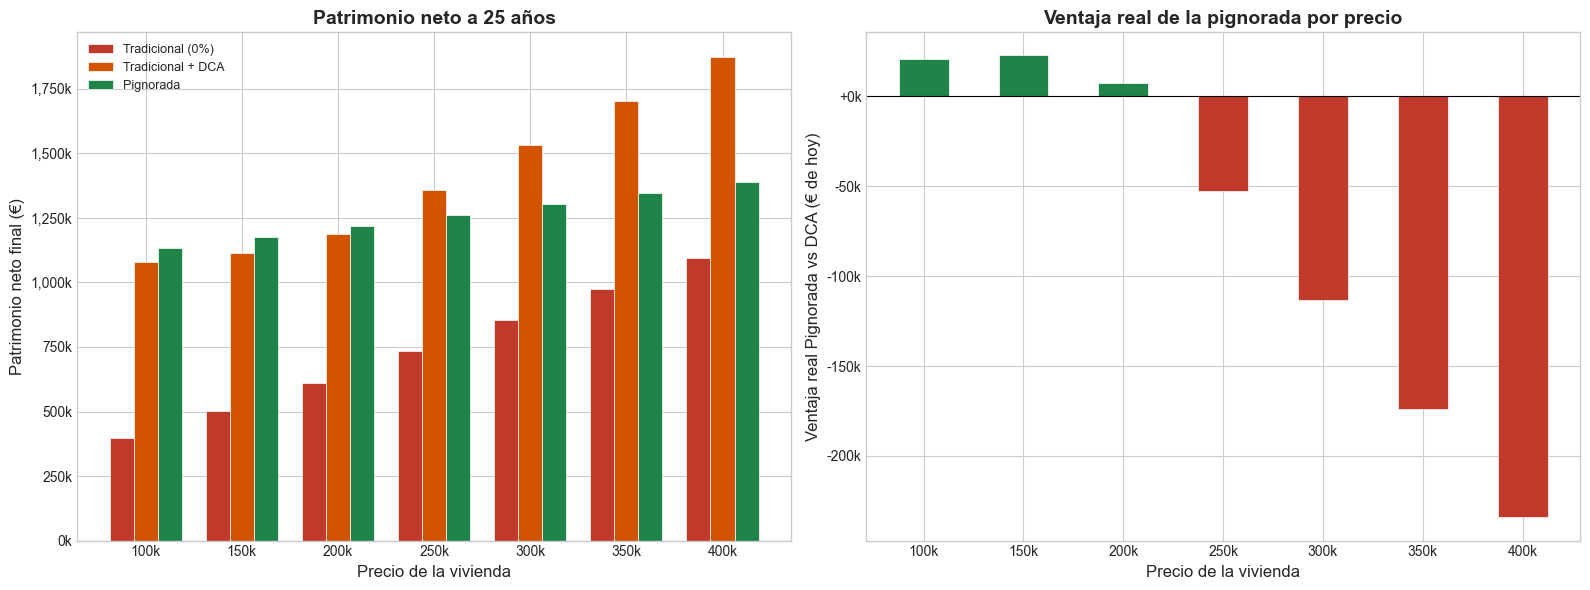

In [52]:
# ── Simulación multi-precio ─────────────────────────────────────
INFLATION_MP = 0.02
price_list = [100_000, 150_000, 200_000, 250_000, 300_000, 350_000, 400_000]

rows = []
for hp in price_list:
    p_h, p_m, p_pay = simulate_pledged(
        hp, INITIAL_CAPITAL, MORTGAGE_YEARS, TIN_PLEDGED,
        returns_sp500.values, HOUSING_APPRECIATION, EXTRA_MONTHLY_SAVINGS,
        ter=TER, life_insurance_rate=LIFE_INSURANCE_RATE, home_insurance_annual=HOME_INSURANCE_ANNUAL)
    d_h, d_m, d_pay, d_tax, d_left = simulate_traditional_dca(
        hp, INITIAL_CAPITAL, COST_BASIS, MORTGAGE_YEARS,
        TIN_TRADITIONAL, returns_sp500.values, HOUSING_APPRECIATION,
        p_pay, EXTRA_MONTHLY_SAVINGS,
        ter=TER, life_insurance_rate=LIFE_INSURANCE_RATE, home_insurance_annual=HOME_INSURANCE_ANNUAL)
    c_h, c_m, c_pay = simulate_traditional_cash(
        hp, INITIAL_CAPITAL, COST_BASIS, MORTGAGE_YEARS,
        TIN_TRADITIONAL, returns_sp500.values, HOUSING_APPRECIATION,
        p_pay, EXTRA_MONTHLY_SAVINGS,
        life_insurance_rate=LIFE_INSURANCE_RATE, home_insurance_annual=HOME_INSURANCE_ANNUAL)
    fhv = hp * (1 + HOUSING_APPRECIATION) ** MORTGAGE_YEARS
    port_p = p_h[-1] - fhv
    port_d = d_h[-1] - fhv
    inv_p = max(0, INITIAL_CAPITAL - hp * 0.10) + EXTRA_MONTHLY_SAVINGS * 12 * MORTGAGE_YEARS
    dca_ms = max(0, p_pay - d_pay) + EXTRA_MONTHLY_SAVINGS
    inv_d = d_left + dca_ms * 12 * MORTGAGE_YEARS
    tax_p = capital_gains_tax_spain(max(0, port_p - inv_p))
    tax_d = capital_gains_tax_spain(max(0, port_d - inv_d))
    adv_neta = (port_p - tax_p) - (port_d - tax_d)
    adv_real = adv_neta / (1 + INFLATION_MP) ** MORTGAGE_YEARS
    # Viabilidad: ¿cubre el capital el 30% para el modelo tradicional?
    gain_ck = max(0, INITIAL_CAPITAL - COST_BASIS)
    net_ck = INITIAL_CAPITAL - capital_gains_tax_spain(gain_ck)
    viable = 'Sí' if net_ck >= hp * 0.30 else 'No'
    rows.append(dict(precio=hp, entrada=hp*0.30, cuota_p=p_pay, cuota_t=d_pay,
                     cash=c_h[-1], dca=d_h[-1], pign=p_h[-1],
                     adv_bruta=p_h[-1]-d_h[-1], adv_real=adv_real, viable=viable))

# ── Tabla resumen ────────────────────────────────────────────────
print('=' * 116)
print('  COMPARATIVA POR PRECIO DE VIVIENDA (25 años, rentabilidades históricas S&P 500)')
print('=' * 116)
print(f"  {'Precio':>10}  {'Entrada':>10}  {'Cuota Pig':>10}  {'Cuota Trad':>11}  {'Patr.Cash':>12}  {'Patr.DCA':>12}  {'Patr.Pign':>12}  {'Vent.Real':>12}  {'Viable':>7}")
print('  ' + '─' * 112)
for r in rows:
    print(f"  {r['precio']:>10,.0f}  {r['entrada']:>10,.0f}  {r['cuota_p']:>10,.0f}  {r['cuota_t']:>11,.0f}  {r['cash']:>12,.0f}  {r['dca']:>12,.0f}  {r['pign']:>12,.0f}  {r['adv_real']:>+12,.0f}  {r['viable']:>7}")
print('=' * 116)
print()
print('  Entrada  = 30% del precio (20%% entrada + 10%% gastos) del modelo tradicional.')
print('  Vent.Real = ventaja real (ajustada inflación 2%%) pignorada vs DCA en € de hoy.')

# ── Gráfico comparativo ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
x_labels = [f'{r["precio"]/1000:.0f}k' for r in rows]
x = np.arange(len(x_labels))
w = 0.25

ax1 = axes[0]
ax1.bar(x - w, [r['cash'] for r in rows], w, color=C_CASH,
        label='Tradicional (0%)', edgecolor='white', linewidth=0.5)
ax1.bar(x, [r['dca'] for r in rows], w, color=C_DCA,
        label='Tradicional + DCA', edgecolor='white', linewidth=0.5)
ax1.bar(x + w, [r['pign'] for r in rows], w, color=C_PLEDGE,
        label='Pignorada', edgecolor='white', linewidth=0.5)
ax1.set_xticks(x)
ax1.set_xticklabels(x_labels)
ax1.set_xlabel('Precio de la vivienda')
ax1.set_ylabel('Patrimonio neto final (€)')
ax1.set_title('Patrimonio neto a 25 años', fontweight='bold')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1000:,.0f}k'))
ax1.legend(fontsize=9)

ax2 = axes[1]
advs = [r['adv_real'] for r in rows]
colors_adv = [C_PLEDGE if a >= 0 else C_CASH for a in advs]
ax2.bar(x, advs, 0.5, color=colors_adv, edgecolor='white', linewidth=0.5)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels(x_labels)
ax2.set_xlabel('Precio de la vivienda')
ax2.set_ylabel('Ventaja real Pignorada vs DCA (€ de hoy)')
ax2.set_title('Ventaja real de la pignorada por precio', fontweight='bold')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1000:+,.0f}k'))

plt.tight_layout()
plt.savefig('figures/price_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Riesgos que el modelo NO contempla

El análisis muestra que, estadísticamente, la hipoteca pignorada es la opción más rentable. Sin embargo, hay factores reales que este modelo simplifica o ignora:

1. **Riesgo de margin call.** Si el mercado cae con fuerza (como en 2008, −38%), el banco puede exigir garantías adicionales o directamente vender tu cartera en el peor momento posible. Esto destruye el interés compuesto de raíz.

2. **Impuestos diferidos (no incluidos en el gráfico principal).** Las cifras del gráfico son brutas. Al liquidar la cartera, Hacienda se lleva hasta un 28% de las ganancias. La ventaja real tras impuestos es menor.

3. **Vinculados y comisiones.** Una hipoteca al 100% suele exigir seguro de vida, de hogar y a veces domiciliar la nómina. Estos costes no están recogidos en el TIN.

4. **Disciplina inversora.** El modelo DCA asume que se invierte exactamente la misma cantidad todos los meses durante 25 años, sin fallar ni un solo mes. En la práctica, casi nadie mantiene esa disciplina tan perfecta.

5. **Disponibilidad del producto.** La hipoteca pignorada es un producto de banca privada. Generalmente requiere tener la cartera en el propio banco y superar un mínimo de patrimonio invertido (suele estar entre 50.000 y 100.000 €).

## 7. Impacto fiscal y conclusión final

Decir que la Pignorada genera X euros más que el DCA es la ventaja bruta. Pero si quisiéramos convertir ese patrimonio en dinero gastable habría que pagar impuestos sobre las plusvalías de la cartera, y tener en cuenta que 100.000 € dentro de 25 años compran bastante menos que 100.000 € hoy (efecto inflación).

A continuación calculo la ventaja **neta** (tras IRPF) y la ventaja **real** (ajustada por inflación al 2% anual), que es la que mide el poder adquisitivo adicional en euros de hoy.

In [53]:
INFLATION_RATE    = 0.02

final_home_value  = HOME_PRICE * (1 + HOUSING_APPRECIATION) ** MORTGAGE_YEARS

# Carteras brutas (sin incluir el valor de la vivienda)
port_pledge_gross = pledge_hist[-1] - final_home_value
port_dca_gross    = dca_hist[-1]    - final_home_value

# Coste base (lo aportado, no tributa)
invested_pledge   = (INITIAL_CAPITAL - HOME_PRICE * 0.10) + (EXTRA_MONTHLY_SAVINGS * 12 * MORTGAGE_YEARS)
invested_dca      = dca_leftover + (dca_monthly_invest * 12 * MORTGAGE_YEARS)

# Plusvalías
gain_pledge = max(0, port_pledge_gross - invested_pledge)
gain_dca    = max(0, port_dca_gross    - invested_dca)

# IRPF
tax_pledge = capital_gains_tax_spain(gain_pledge)
tax_dca    = capital_gains_tax_spain(gain_dca)

# Neto tras impuestos
port_pledge_net   = port_pledge_gross - tax_pledge
port_dca_net      = port_dca_gross    - tax_dca
net_advantage     = port_pledge_net   - port_dca_net

# Ajuste por inflación (poder adquisitivo en euros de hoy)
real_advantage    = net_advantage / ((1 + INFLATION_RATE) ** MORTGAGE_YEARS)

print("=" * 60)
print("  IMPACTO FISCAL (liquidación hipotética al año 25)")
print("=" * 60)
print(f"  {'Concepto':<38} {'Pignorada':>10}  {'DCA':>10}")
print(f"  {'─'*56}")
print(f"  {'Cartera bruta (sin vivienda)':<38} {port_pledge_gross:>10,.0f}€  {port_dca_gross:>10,.0f}€")
print(f"  {'Capital aportado (no tributa)':<38} {invested_pledge:>10,.0f}€  {invested_dca:>10,.0f}€")
print(f"  {'Plusvalías':<38} {gain_pledge:>10,.0f}€  {gain_dca:>10,.0f}€")
print(f"  {'IRPF a pagar':<38} {tax_pledge:>10,.0f}€  {tax_dca:>10,.0f}€")
print(f"  {'Cartera neta (tras IRPF)':<38} {port_pledge_net:>10,.0f}€  {port_dca_net:>10,.0f}€")
print()
print("=" * 60)
print("  VENTAJA FINAL DE LA PIGNORADA")
print("=" * 60)
print(f"  Ventaja bruta (nominal, gráfico):     {pledge_hist[-1] - dca_hist[-1]:>+12,.0f} €")
print(f"  Ventaja neta (tras IRPF):             {net_advantage:>+12,.0f} €")
print(f"  Ventaja real (poder adquisitivo hoy): {real_advantage:>+12,.0f} €")
print("=" * 60)
print()
print(f"  En términos de poder adquisitivo a euros de 2026,")
print(f"  la hipoteca pignorada genera {real_advantage:+,.0f} € adicionales")
print(f"  respecto al modelo Tradicional + DCA.")

  IMPACTO FISCAL (liquidación hipotética al año 25)
  Concepto                                Pignorada         DCA
  ────────────────────────────────────────────────────────
  Cartera bruta (sin vivienda)              464,722€     516,280€
  Capital aportado (no tributa)             155,000€     209,236€
  Plusvalías                                309,722€     307,044€
  IRPF a pagar                               74,602€      73,852€
  Cartera neta (tras IRPF)                  390,120€     442,428€

  VENTAJA FINAL DE LA PIGNORADA
  Ventaja bruta (nominal, gráfico):          -51,558 €
  Ventaja neta (tras IRPF):                  -52,308 €
  Ventaja real (poder adquisitivo hoy):      -31,883 €

  En términos de poder adquisitivo a euros de 2026,
  la hipoteca pignorada genera -31,883 € adicionales
  respecto al modelo Tradicional + DCA.
